In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('/content/drive/MyDrive/ML_Projects/Customer_Segmentation/online_retail.csv')

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.shape

(541909, 8)

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [9]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [10]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [11]:
df[df["InvoiceNo"].str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [12]:
df = df[~df["InvoiceNo"].str.startswith("C")]

In [13]:
#remove returns and cancellations
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [14]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [15]:
df['CustomerID'] = df['CustomerID'].astype(str)

In [16]:
df.shape

(397884, 9)

In [17]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,TotalPrice
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,168469.600000
std,179.331775,NaN,22.097877,309.071041


In [18]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
TotalPrice,0


Create RFM Features

In [19]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [20]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(reference_date)

2011-12-10 12:50:00


In [21]:
rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (
        reference_date - x.max()
    ).days,

    "InvoiceNo": "nunique",

    "TotalPrice": "sum"

})

In [22]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [23]:
rfm = rfm.reset_index()

In [24]:
print(rfm.shape)



(4338, 4)


In [25]:
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [26]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


Outlier Treatment

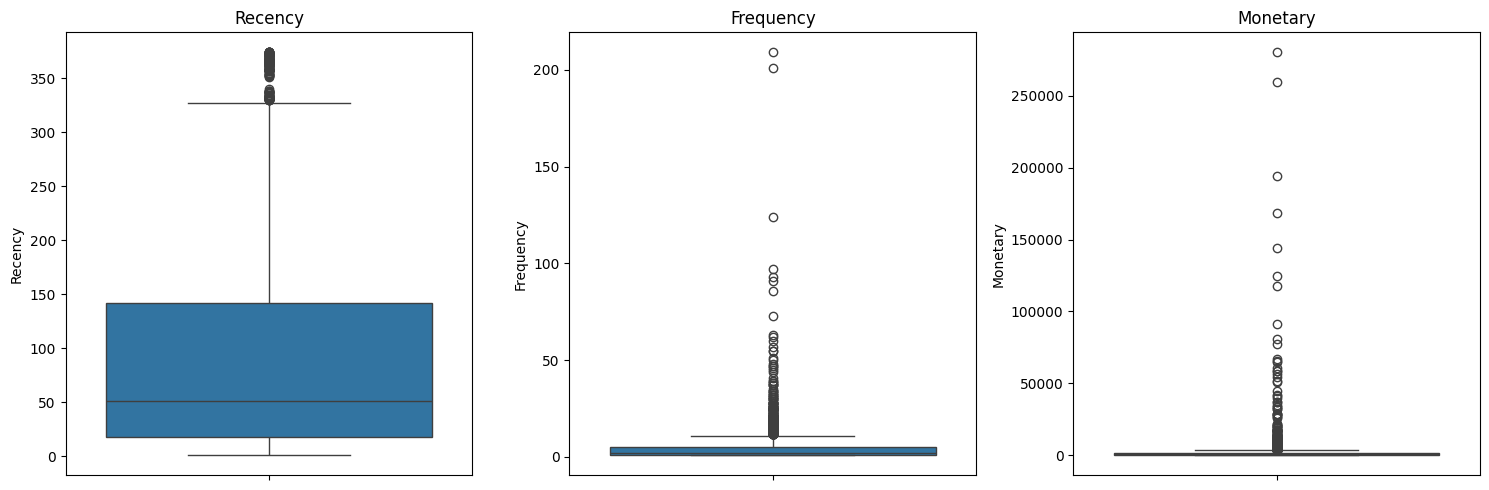

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=rfm["Recency"], ax=axes[0])
axes[0].set_title("Recency")

sns.boxplot(y=rfm["Frequency"], ax=axes[1])
axes[1].set_title("Frequency")

sns.boxplot(y=rfm["Monetary"], ax=axes[2])
axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

In [28]:
import numpy as np

rfm_log = rfm.copy()

rfm_log[["Recency", "Frequency", "Monetary"]] = np.log1p(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)

 Feature Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)

In [30]:
print(rfm_scaled.shape)

(4338, 3)


Finding optimal Number of Clusters (K)

Elbow Method

In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(2, 20):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

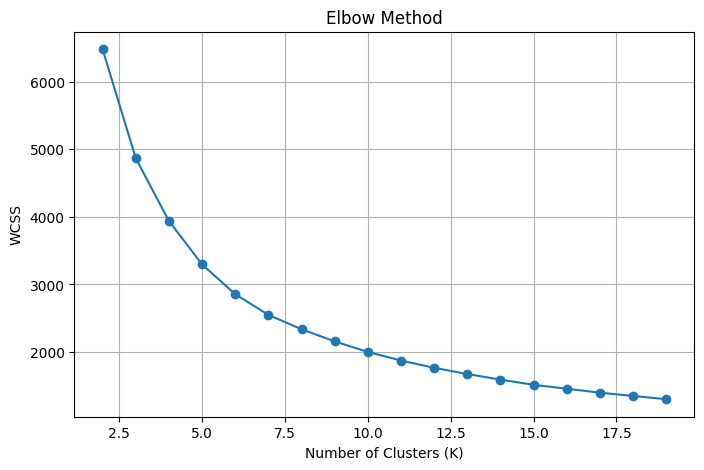

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 20),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [33]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

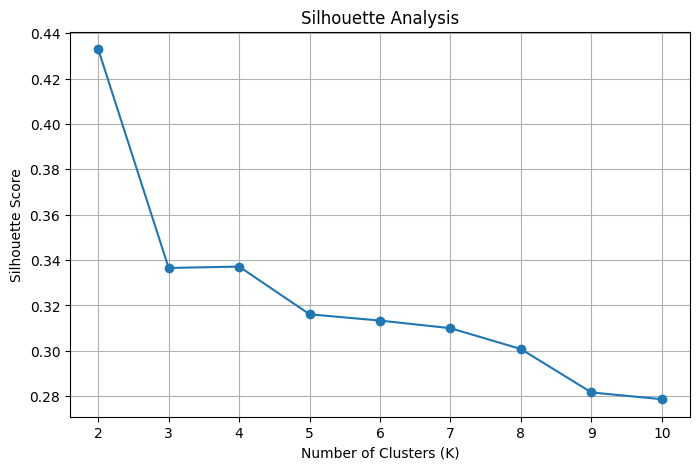

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

In [38]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [39]:
rfm["Cluster"].value_counts()

,count
Cluster,
3,1612
2,1173
0,837
1,716


In [40]:
cluster_profile = rfm.groupby("Cluster").agg({

    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"

}).round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,18.12,2.15,551.82
1,12.13,13.71,8074.27
2,71.08,4.08,1802.83
3,182.50,1.32,343.45


In [41]:
cluster_profile["Count"] = rfm["Cluster"].value_counts()

cluster_profile

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,18.12,2.15,551.82,837
1,12.13,13.71,8074.27,716
2,71.08,4.08,1802.83,1173
3,182.50,1.32,343.45,1612


In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

In [43]:
pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = rfm["Cluster"]

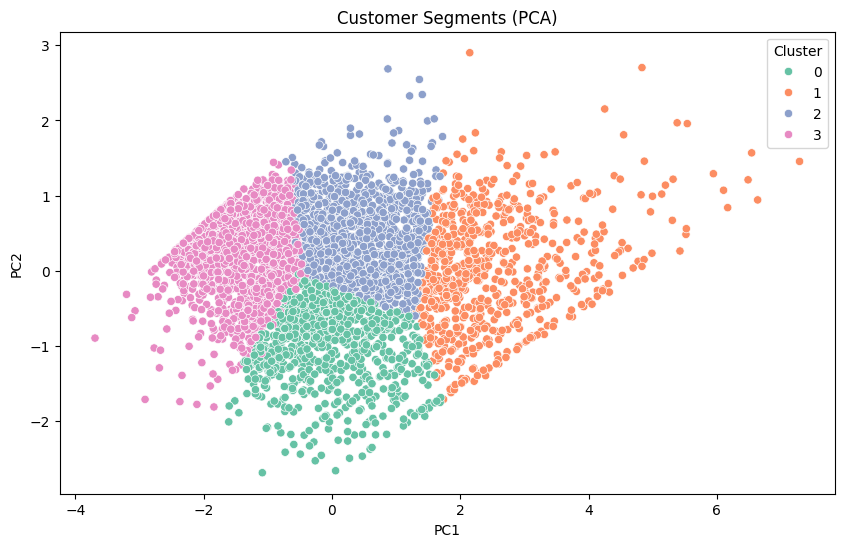

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments (PCA)")
plt.show()

In [45]:
plt.savefig("customer_segments.png")

<Figure size 640x480 with 0 Axes>

In [46]:
cluster_names = {
    0: "Regular Customer",
    1: "VIP Customer",
    2: "Loyal Customer",
    3: "At-Risk Customer"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

In [47]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,2,Loyal Customer
1,12347.0,2,7,4310.00,1,VIP Customer
2,12348.0,75,4,1797.24,2,Loyal Customer
3,12349.0,19,1,1757.55,0,Regular Customer
4,12350.0,310,1,334.40,3,At-Risk Customer


In [50]:
import joblib

joblib.dump(kmeans, "/content/drive/MyDrive/ML_Projects/Customer_Segmentation/kmeans.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/ML_Projects/Customer_Segmentation/scaler.pkl")

['/content/drive/MyDrive/ML_Projects/Customer_Segmentation/scaler.pkl']

In [49]:
rfm.to_csv(
    "customer_segments.csv",
    index=False
)